# Chapter 7: The Casino at Los Alamos
Sample a future distribution, measure Monte Carlo error and approximate a
posterior with a symmetric-proposal Metropolis chain. All data are synthetic.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.stats import beta
rng=begin(7)

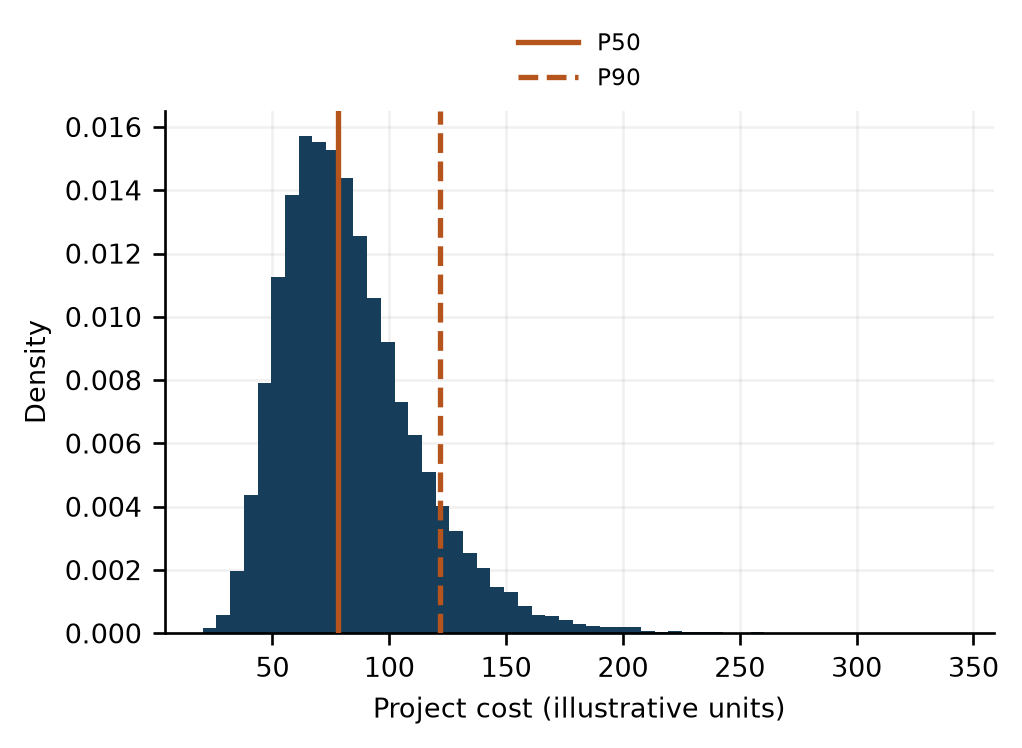

In [2]:
cost=rng.lognormal(4,.4,20000)+rng.lognormal(3,.6,20000)
plt.figure(); plt.hist(cost,bins=55,density=True)
for q,ls,col in [(.5,'-','#b5541c'),(.9,'--','#b5541c')]: plt.axvline(np.quantile(cost,q),ls=ls,color=col,lw=1.6,zorder=3,label=f'P{int(q*100)}')
plt.xlabel('Project cost (illustrative units)'); plt.ylabel('Density'); plt.legend()
save(7,1,'A distribution is more useful than one budget','Independent synthetic lognormal cost components. Quantiles describe this assumed model, not empirical project risk.','## Part Two: Beyond the Weapons Lab')

## More draws reduce simulation noise, not model error
Repeated independent normal samples estimate a known zero mean. The root-MSE
comparison checks the familiar square-root rate under finite variance.

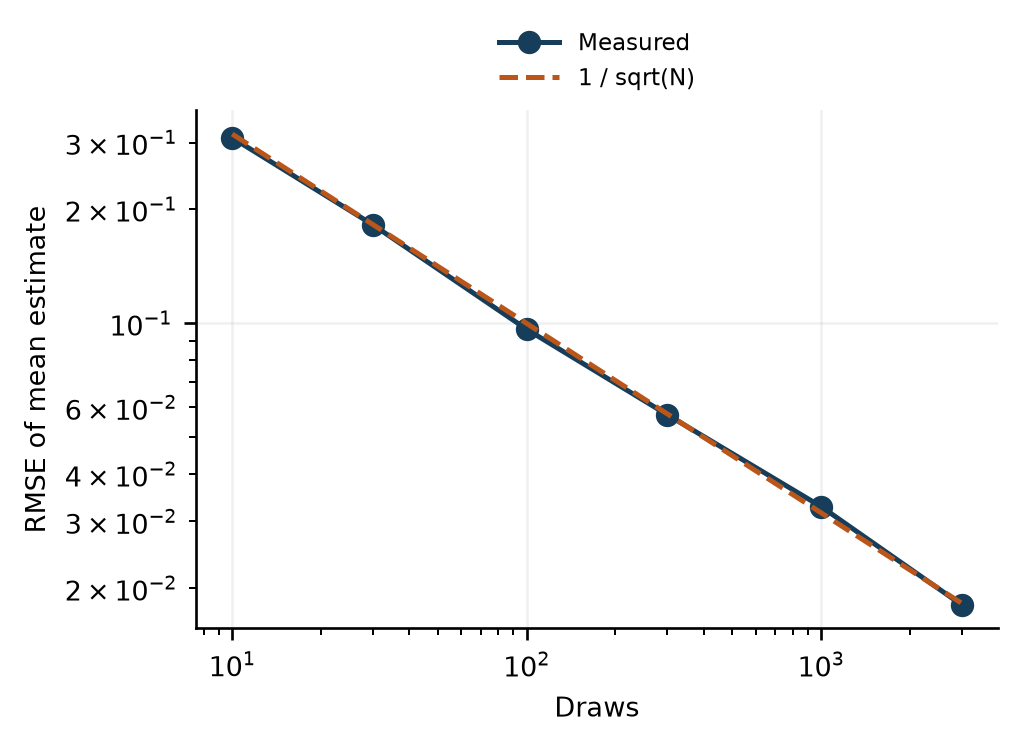

In [3]:
sizes=np.array([10,30,100,300,1000,3000]); rms=[]
for n in sizes: rms.append(np.sqrt(np.mean(rng.normal(size=(300,n)).mean(axis=1)**2)))
plt.figure(); plt.loglog(sizes,rms,'o-',label='Measured'); plt.loglog(sizes,1/np.sqrt(sizes),'--',label='1 / sqrt(N)'); plt.xlabel('Draws'); plt.ylabel('RMSE of mean estimate'); plt.legend()
save(7,2,'The price of another decimal place','Repeated Monte Carlo estimates of a standard normal mean. More simulation cannot repair a wrong data-generating model.','## Part Four: Sampling the Future')

## Metropolis samples a Beta posterior
The Gaussian random-walk proposal is symmetric, so proposal terms cancel in the
acceptance ratio. An asymmetric proposal requires the full Hastings correction.

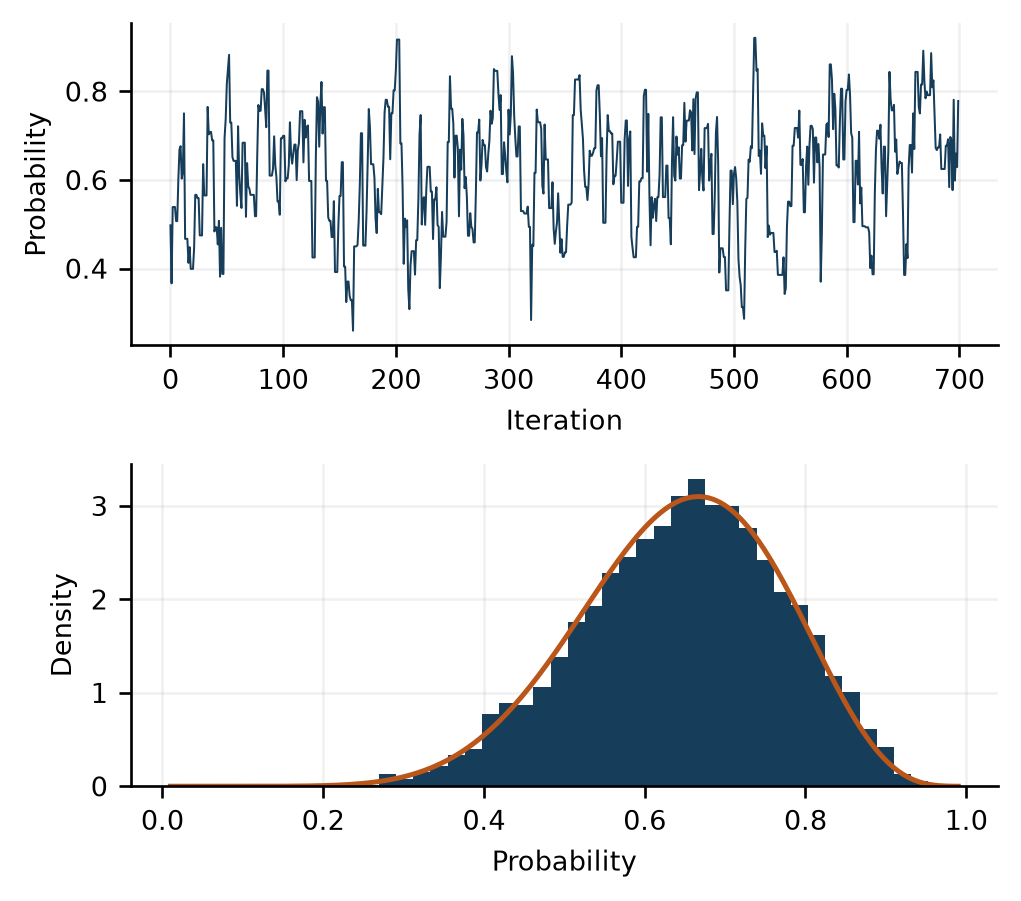

Acceptance rate: 0.7205 mean: 0.6468945131593563 exact: 0.6428571428571429


In [4]:
chain=np.empty(12000); current=.5; accepted=0
for i in range(len(chain)):
    candidate=current+rng.normal(0,.12)
    if 0<candidate<1 and np.log(rng.random())<beta.logpdf(candidate,9,5)-beta.logpdf(current,9,5):
        current=candidate; accepted+=1
    chain[i]=current
fig,axes=plt.subplots(2,1,figsize=(4.3,3.8)); axes[0].plot(chain[:700],lw=.6); axes[0].set_ylabel('Probability'); axes[0].set_xlabel('Iteration'); axes[1].hist(chain[2000:],bins=35,density=True); x=np.linspace(.01,.99,200); axes[1].plot(x,beta.pdf(x,9,5)); axes[1].set_xlabel('Probability'); axes[1].set_ylabel('Density')
save(7,3,'A chain can recover a posterior distribution','Synthetic Beta(9,5) target with a symmetric Metropolis proposal. The density uses draws after a 2,000-iteration warm-up.','## Part Three: The MCMC Revolution',fig)
print('Acceptance rate:',accepted/len(chain),'mean:',chain[2000:].mean(),'exact:',9/14)
assert abs(chain[2000:].mean()-9/14)<.04

## Limits and exercise
Make the proposal scale very small and then very large; compare mixing. Use
multiple chains and effective sample sizes for serious inference. HMC, Gibbs,
variational inference and Gaussian processes are separate extensions. VI maximizes
an evidence lower bound; sampling uncertainty is different from parameter uncertainty.

## Diagnose Monte Carlo precision rather than trusting one attractive trace
Four dispersed chains target the same Beta(9,5) density. We split each retained
chain in half, compare between/within-chain variation, and estimate effective
sample size from autocorrelation pairs up to their first nonpositive sum.
This classical split-R-hat/initial-positive-pair check is transparent teaching
code, not a substitute for modern rank-normalized bulk/tail diagnostics.
Changing proposal_scale to .001 produces a sticky sampler: acceptance can be
high while exploration is poor. More nominal draws do not ensure precision.

In [5]:
from statsmodels.tsa.stattools import acf
proposal_scale=.12
retained=[]
for start in [.1,.3,.7,.9]:
    state=start; values=[]
    for iteration in range(7000):
        proposal=state+rng.normal(0,proposal_scale)
        if 0<proposal<1 and np.log(rng.random())<beta.logpdf(proposal,9,5)-beta.logpdf(state,9,5): state=proposal
        if iteration>=2000: values.append(state)
    retained.append(values)
chains=np.asarray(retained); split=np.concatenate([chains[:,:2500],chains[:,2500:]],axis=0)
W=split.var(axis=1,ddof=1).mean(); B=2500*split.mean(axis=1).var(ddof=1)
rhat=np.sqrt(((2499/2500)*W+B/2500)/W)
correlations=np.mean([acf(row,nlags=500,fft=True) for row in chains],axis=0)
positive_pairs=[]
for lag in range(1,499,2):
    pair=correlations[lag]+correlations[lag+1]
    if pair<=0: break
    positive_pairs.append(pair)
ess=chains.size/(1+2*sum(positive_pairs)); mcse=chains.std(ddof=1)/np.sqrt(ess)
print({'classical_split_Rhat':float(rhat),'approximate_ESS':float(ess),'mean_MCSE':float(mcse),'posterior_mean':float(chains.mean()),'analytic_mean':9/14})
assert abs(chains.mean()-9/14)<.03 and rhat<1.1
print('Interpretation: compare the mean error with MCSE, but do not treat an R-hat threshold as proof that all tails were explored.')

{'classical_split_Rhat': 1.0019526919145239, 'approximate_ESS': 2395.82976617132, 'mean_MCSE': 0.002521859752411284, 'posterior_mean': 0.6450588643884531, 'analytic_mean': 0.6428571428571429}
Interpretation: compare the mean error with MCSE, but do not treat an R-hat threshold as proof that all tails were explored.


<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV component,mean,sd for positive lognormal components, with mean > 0 and sd >= 0 in common additive units. Config samples,seed and correlation assumption. Arithmetic-scale mean/sd are not log-scale normal parameters. Other distributions require an explicitly adapted model.

Minimal **format illustration**, not sufficient training data:

```csv
component,mean,sd
Labor,100,20
Materials,50,15
```

## Explain the mechanism

Monte Carlo pushes assumptions through a calculation by repeated sampling. Direct simulation samples specified inputs; MCMC approximates a target distribution through dependent states. The number of draws is not a substitute for trustworthy assumptions.

## Work through the arithmetic

If an indicator event occurs in 2,000 of 10,000 independent draws, estimated probability is .2 and approximate Monte Carlo standard error is sqrt(.2×.8/10000)=.004. Four times as many draws reduces that standard error to .002. This is simulation precision, not uncertainty that the assumed risk model is correct.

## Adapt the lesson to reader data

Replace the cost-generation block with named components and a documented joint simulator. Do not pass arithmetic means directly as the mean argument of a lognormal generator. Keep the Metropolis demonstration separate: it targets Beta(9,5), whose analytic mean is 9/14, not a cost model.

For this chapter, settle these questions before fitting: What outcome and units matter? Which input distributions are measured or elicited? Which dependencies matter? What precision is needed for the decision?

## Interpret the actual lesson outputs

The cost histogram reflects independent assumed lognormal components. The sample-size plot illustrates the square-root precision rate under finite variance. The single-chain Beta density comparison and mean assertion do not implement multiple-chain convergence or ESS diagnostics.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `quantile,total`.
- `summary.json`: `mean,mean_mcse,analytic_mean,samples,correlation` plus method, interpretation, assumptions, not_done and status.

Positive arithmetic means and nonnegative SDs define lognormal components. correlation is shared latent-normal correlation in [0,1), not the resulting components’ Pearson correlation. The adapter simulates totals directly; it does not run MCMC or report budget exceedance unless added separately.

## Decide what the evidence supports

More draws reduce Monte Carlo error, not model error. Independent-draw formulas do not apply to correlated MCMC draws without an effective-sample adjustment. Acceptance rate and a plausible trace are insufficient convergence evidence.

With only unweighted scenarios, report scenario outcomes rather than invented percentiles. With unknown dependence, show several defensible dependence scenarios. If serious MCMC diagnostics are absent, report the missing diagnostics and use an analytic/direct sampler when available.

The applied deliverable must make these items inspectable: `results.csv` columns: `quantile,total`; `summary.json` keys: `mean,mean_mcse,analytic_mean,samples,correlation` plus method, interpretation, assumptions, not_done and status. Return input distributions and provenance, dependence assumptions, seed/draw count, outcome quantiles, exceedance probabilities, Monte Carlo precision and separate model-sensitivity results.

## Three exercises with worked solutions

### Exercise 1

Independent simulated mean has SE=.1 at N=1000. Approximate SE at N=4000?

**Worked solution.** SE=.05 under the same finite-variance model.

### Exercise 2

You observe 90% interval coverage across simulator draws. Is empirical business coverage established?

**Worked solution.** No. Simulator draws came from assumed distributions; real later outcomes are required to assess operational coverage.

### Exercise 3

MCMC has 10,000 draws but ESS=100. Which count informs mean precision?

**Worked solution.** Effective sample size, approximately 100, subject to valid diagnostics; raw draw count overstates independent information.

## Business-reader application

Use this request with the skill:

> Apply chapter 7 to cost_components.csv, preserve the stated dependence assumptions, calculate budget-exceedance probabilities and distinguish simulation error from model uncertainty.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch07.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch07.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(7, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch07-workshop-results.csv', index=False)
_ = (workshop_output/'ch07-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Monte Carlo sum of lognormal components with a shared latent factor
Status: passed

Interpretation: 10000 draws over 3 components: median total 177.2, 90th percentile 219.9, mean 180 against an analytic mean of 180 (Monte Carlo error 0.299). Dependence rho=0 is imposed on latent normal draws, not as the Pearson correlation of the components. The quantiles describe the supplied assumptions, not measured real-world risk.

Assumptions:
  - Each component is lognormal with the stated mean and standard deviation
  - Dependence is one shared normal factor with the same weight for every component
  - Components add; there are no other interactions
Not done:
  - No model uncertainty layer: the distribution shapes are taken as given
  - No calibration against realized totals

Evidence:
  mean: 180
  mean_mcse: 0.2993
  analytic_mean: 180
  samples: 10000
  correlation: 0

Table: 5 rows, columns ['quantile', 'total']

 quantile   total
     0.10 143.722
     0.50 177.201
     0.80 204.24

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **Are the input distributions and their dependence stated, and where did each come from?**
   A bad answer looks like this: A Monte Carlo over invented inputs produces a precise picture of the assumptions, not of the world.

2. **Is the Monte Carlo error small enough that another seed would give the same answer?**
   A bad answer looks like this: A quantile that moves with the seed has not converged, whatever the sample size sounds like.

3. **Which single input moves the answer most, and is that the one with the weakest evidence?**
   A bad answer looks like this: A tornado that is never drawn hides the input that decides the result.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).